# Theta vs Random


1. **Načtou se data**

2. **Nastavení**

3. **Random metoda**

4. **Theta metoda**

5. **Pro každou metodu se fituje SAPCE model**

6. **Zkouší se více konfigurací modelu**

7. **Spočítají se chyby**

8. **Vykreslí se grafy**

In [47]:
import copy
import random
import traceback
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from UQpy.distributions import Normal, Uniform, JointIndependent
from UQpy.sampling.ThetaCriterionPCE import ThetaCriterionPCE

import SAPCE


In [50]:
# Načtení dat - ze souboru
def load_dataset(data_file):
    data = pd.read_csv(data_file, sep=";", header=0)

    for col in data.columns:
        if data[col].dtype == object:
            data[col] = pd.to_numeric(
                data[col].astype(str).str.replace(",", ".", regex=False),
                errors="raise"
            )

    arr = data.to_numpy()
    X = arr[:, :12]
    Y = arr[:, 12:]

    if X.shape[1] != 12:
        raise ValueError(f"Dataset {data_file} has {X.shape[1]} input columns, expected 12")

    if Y.shape[1] == 0:
        raise ValueError(f"Dataset {data_file} has no output columns after the first 12 columns")

    return X, Y


Nastavení

In [49]:
# Nastavení
DATA_FILES = [
    # "Oakwood_NVM.csv",
 #  "Oakwood_N.csv",
   #  "Oakwood_V.csv",
    "Oakwood_M.csv",
]

SEED = 1
N_REPEATS = 20
TEST_SIZE = 300

# velikosti trénovací množiny
nsim = np.arange(15, 100, 10)

# Grid - pro různé soubor může být výhodné jiné nastavení Sapce, proto hledám nejlepsí nastavení
degree_list = [2, 3, 5]
cond_list = [10,100,1000]
cr_list = [1e-8]
ratio_list = [0.30, 0.40, 0.50, 0.70]

METHODS = ["Random", "Theta"]

# Theta zvolení kolik výstupů uvidí, none = všechny
# None = použije všechny výstupy daného datasetu.
THETA_OUTPUT_INDICES = None

# KPro kontrolu převodu PCE
VERIFY_PCE_CONVERSION = True
PCE_VERIFY_ATOL = 1e-8
PCE_VERIFY_RTOL = 1e-6

n_inputs = 12
linear_terms = n_inputs + 1


In [53]:
# Rozdělení vstupů
marg = [
    Normal(13, 1),
    Uniform(30, 40),
    Uniform(2, 1),
    Normal(65, 5),
    Normal(30, 5),
    Normal(30, 1),
    Uniform(0.6, 0.5),
    Uniform(2, 1),
    Normal(130, 10),
    Normal(5, 1),
    Normal(42, 1),
    Uniform(0.45, 0.2)
]

joint = JointIndependent(marginals=marg)


In [54]:

# Univerzální predikce PCE objektu.
def predict_pce(pce, X_in):
    X_in = np.asarray(X_in, dtype=float)

    for name in ["predict", "evaluate", "run"]:
        if hasattr(pce, name):
            try:
                return np.asarray(getattr(pce, name)(X_in))
            except TypeError:
                pass

    if callable(pce):
        return np.asarray(pce(X_in))

    raise AttributeError("PCE object has no usable prediction method")


# Převod multi-output PCE na list jedno-výstupových PCE.
def pce_multioutput_to_singleoutput_list(pce, output_indices=None):
    coef = np.asarray(pce.coefficients)

    if coef.ndim == 1:
        coef = coef.reshape(-1, 1)

    n_outputs = coef.shape[1]

    if output_indices is None:
        output_indices = range(n_outputs)
    else:
        output_indices = [int(i) for i in output_indices]

    pce_list = []

    for j in output_indices:
        if j < 0 or j >= n_outputs:
            raise IndexError(f"output index {j} out of range")

        pce_j = copy.deepcopy(pce)
        pce_j.coefficients = coef[:, [j]]
        pce_list.append(pce_j)

    return pce_list


# Hlavní funkce pro ThetaCriterionPCE.
def select_theta_points_from_sapce(
    sapce,
    existing_samples,
    candidate_samples,
    nsamples=1,
    candidate_indices=None,
    output_indices=None,
    pce_weights=None,
    samples_weights=None,
    candidate_weights=None,
    verify_conversion=True,
    x_verify=None,
    atol=1e-8,
    rtol=1e-6,
):
    existing_samples = np.asarray(existing_samples, dtype=float)
    candidate_samples = np.asarray(candidate_samples, dtype=float)

    if candidate_samples.shape[0] == 0:
        raise ValueError("candidate_samples is empty")

    nsamples = int(nsamples)
    nsamples = max(1, min(nsamples, candidate_samples.shape[0]))

    pce_list = pce_multioutput_to_singleoutput_list(
        sapce.pce,
        output_indices=output_indices,
    )

    theta = ThetaCriterionPCE(pce_list)

    selected_pos = theta.run(
        existing_samples=existing_samples,
        candidate_samples=candidate_samples,
        nsamples=nsamples,
        samples_weights=samples_weights,
        candidate_weights=candidate_weights,
        pce_weights=pce_weights,
    )

    selected_pos = np.asarray(selected_pos, dtype=int).ravel()

    if selected_pos.size == 0:
        raise RuntimeError("ThetaCriterionPCE returned no selected positions")

    if np.any(selected_pos < 0) or np.any(selected_pos >= candidate_samples.shape[0]):
        raise IndexError(f"ThetaCriterionPCE returned positions outside candidate range: {selected_pos}")

    selected_global = None
    if candidate_indices is not None:
        candidate_indices = np.asarray(candidate_indices, dtype=int)
        selected_global = candidate_indices[selected_pos]

    return {
        "selected_pos": selected_pos,
        "selected_global_idx": selected_global,
        "conversion_info": None,
        "pce_list": pce_list,
    }


Funkce pro Sapce

In [55]:
def max_ratio_for_n(n_train):
    # Určí max. poměr
    min_ratio = (linear_terms + 0.5) / n_train

    if n_train < 30:
        base = 0.90
    elif n_train < 60:
        base = 0.70
    elif n_train < 100:
        base = 0.55
    elif n_train < 200:
        base = 0.60
    else:
        base = 0.70

    return min(0.95, max(base, min_ratio))


def ratio_candidates(n_train):
    # Vybere poměry
    upper = max_ratio_for_n(n_train)

    out = [
        r for r in ratio_list
        if r <= upper and int(np.floor(r * n_train)) >= linear_terms
    ]

    if len(out) == 0:
        out = [min(0.95, (linear_terms + 0.5) / n_train)]

    if not any(np.isclose(upper, r) for r in out):
        if int(np.floor(upper * n_train)) >= linear_terms:
            out.append(upper)

    return sorted(out)


def admissible_neighbors_fn():
    # Najde sousedy
    if hasattr(SAPCE, "admissible_neighbors"):
        return SAPCE.admissible_neighbors

    glb = SAPCE.SensitivityAdaptivePCE.construct_adaptive_basis.__globals__

    if "admissible_neighbors" in glb:
        return glb["admissible_neighbors"]

    raise RuntimeError("admissible_neighbors not found")


def filter_indices(indices, degree):
    # Filtruje indexy
    out = []

    for idx in indices:
        idx = np.asarray(idx, dtype=int)

        if np.sum(idx) <= degree and np.all(idx <= degree):
            out.append(idx.tolist())

    return out


def adaptive_basis_rollback(sapce, cond_limit, ratio_limit):
    # Staví bázi
    neigh = admissible_neighbors_fn()
    n_train = sapce.exp_design_in.shape[0]
    max_terms = int(np.floor(ratio_limit * n_train))

    while True:
        terms = len(sapce.pce.multi_index_set)

        if terms >= n_train:
            return "basis_ge_n_train"

        if terms >= max_terms:
            return "basis_ge_ratio"

        if sapce.condition_number > cond_limit:
            return "condition_too_large"

        new_idx = neigh(
            sapce.active_multi_indices[-1],
            sapce.active_multi_indices
        )

        new_idx = filter_indices(new_idx, sapce.max_partial_degree)

        if len(new_idx) == 0:
            return "no_new_indices"

        proposed_terms = (
            len(sapce.active_multi_indices)
            + len(sapce.admissible_multi_indices)
            + len(new_idx)
        )

        if proposed_terms >= n_train:
            return "proposed_ge_n_train"

        if proposed_terms > max_terms:
            return "proposed_ge_ratio"

        old_active = copy.deepcopy(sapce.active_multi_indices)
        old_admissible = copy.deepcopy(sapce.admissible_multi_indices)
        old_multi = copy.deepcopy(sapce.pce.multi_index_set)

        sapce.admissible_multi_indices += new_idx
        sapce.set_multi_index_set(
            sapce.active_multi_indices + sapce.admissible_multi_indices
        )
        sapce.compute_coefficients()

        if sapce.condition_number > cond_limit:
            sapce.active_multi_indices = old_active
            sapce.admissible_multi_indices = old_admissible
            sapce.set_multi_index_set(old_multi)
            sapce.compute_coefficients()

            return "rollback"

        i0 = len(sapce.active_multi_indices)
        coef = np.asarray(sapce.pce.coefficients[i0:])

        if coef.size == 0:
            return "no_coefficients"

        if coef.ndim == 1:
            score = np.abs(coef)
        else:
            score = np.sum(np.abs(coef), axis=1)

        best = int(np.argmax(score))
        sapce.active_multi_indices.append(
            sapce.admissible_multi_indices.pop(best)
        )


def make_split(n_total, test_size, max_train_size, seed):
    # Rozdělí indexy
    rng = random.Random(seed)
    idx = list(range(n_total))
    rng.shuffle(idx)

    test_idx = idx[:test_size]
    train_pool = idx[test_size:test_size + max_train_size]
    remaining_pool = idx[test_size + max_train_size:]

    return test_idx, train_pool, remaining_pool


def split_data(X, Y, train_idx, test_idx):
    # Rozdělí data
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    return X[train_idx], Y[train_idx], X[test_idx], Y[test_idx]


Konfigurace

In [56]:
# Nejlepší konfigurace

def maximum_absolute_error_per_output(pce, Xte, Yte):
    # Predikce
    y_pred = np.asarray(predict_pce(pce, Xte), dtype=float)

    # Skutečnost
    y_true = np.asarray(Yte, dtype=float)

    if y_pred.ndim == 1:
        y_pred = y_pred[:, None]

    if y_true.ndim == 1:
        y_true = y_true[:, None]

    if y_pred.shape != y_true.shape:
        raise ValueError(f"Prediction shape {y_pred.shape} does not match Yte shape {y_true.shape}")

    # Max chyba
    return np.max(np.abs(y_pred - y_true), axis=0)


def fit_one_config(Xtr, Ytr, Xte, Yte, degree, cond_limit, ratio_limit, cr, return_model=False):
    # SAPCE model
    sapce = SAPCE.SensitivityAdaptivePCE(
        pdf=joint,
        exp_design_in=Xtr,
        exp_design_out=Ytr,
        max_partial_degree=degree,
        num_inputs=12
    )

    # Adaptivní báze
    status = adaptive_basis_rollback(sapce, cond_limit, ratio_limit)

    # Počet členů
    terms_before = len(sapce.pce.multi_index_set)

    # Prořezání PCE
    sapce.construct_pruned_pce(cr=cr)

    # Počet členů
    terms_after = len(sapce.pce.multi_index_set)

    # Validační chyba
    err = np.asarray(sapce.pce.validation_error(Xte, Yte)).ravel()

    # Max chyba
    max_abs_err = maximum_absolute_error_per_output(sapce.pce, Xte, Yte)

    # Podmíněnost
    cond = float(sapce.condition_number)

    # Počet členů
    terms = len(sapce.pce.multi_index_set)

    # Poměr báze
    ratio = terms / Xtr.shape[0]

    # Platnost modelu
    valid = (
        np.all(np.isfinite(err))
        and np.all(err >= 0)
        and np.all(np.isfinite(max_abs_err))
        and np.all(max_abs_err >= 0)
        and cond <= cond_limit
        and terms < Xtr.shape[0]
        and ratio <= ratio_limit
    )

    # Výsledky
    out = {
        "degree": degree,
        "cond_limit": cond_limit,
        "ratio_limit": ratio_limit,
        "cr": cr,
        "err": err,
        "max_abs_err": max_abs_err,
        "mean": float(np.mean(err)),
        "median": float(np.median(err)),
        "max": float(np.max(err)),
        "max_abs_mean": float(np.mean(max_abs_err)),
        "max_abs_median": float(np.median(max_abs_err)),
        "max_abs_max": float(np.max(max_abs_err)),
        "cond": cond,
        "terms": terms,
        "ratio": ratio,
        "removed": terms_before - terms_after,
        "status": status,
        "valid": valid
    }

    # Vrácení modelu
    if return_model:
        out["sapce"] = sapce

    return out


def find_best_config(Xtr, Ytr, Xte, Yte, n_train):
    # Všechny výsledky
    results = []

    # Test konfigurací
    for degree in degree_list:
        for cond_limit in cond_list:
            for ratio_limit in ratio_candidates(n_train):
                for cr in cr_list:
                    try:
                        results.append(
                            fit_one_config(
                                Xtr, Ytr, Xte, Yte,
                                degree, cond_limit, ratio_limit, cr,
                                return_model=False,
                            )
                        )
                    except Exception:
                        pass

    # Platné modely
    valid = [r for r in results if r["valid"]]

    # Bez modelu
    if len(valid) == 0:
        return None, results

    # Skóre modelu
    def score(r):
        return (
            r["mean"]
            + 1e-5 * r["ratio"]
            + 1e-8 * np.log10(r["cond"] + 1.0)
        )

    # Nejlepší model
    return min(valid, key=score), results


In [ ]:
# Jeden běh
def run_dataset(data_file, repeat_id=0, seed=SEED):
    dataset_name = os.path.splitext(os.path.basename(data_file))[0]

    X, Y = load_dataset(data_file)

    max_train_size = int(np.max(nsim))

    # Split dat
    test_idx, prefix_train_pool, remaining_pool = make_split(
        n_total=X.shape[0],
        test_size=TEST_SIZE,
        max_train_size=max_train_size,
        seed=seed,
    )

    initial_n = int(np.min(nsim))
    initial_train_idx = prefix_train_pool[:initial_n]

    # Theta pool
    all_non_test = [i for i in range(X.shape[0]) if i not in set(test_idx)]
    theta_candidate_pool = [i for i in all_non_test if i not in set(initial_train_idx)]

    train_indices_by_method = {
        "Random": prefix_train_pool,
    }

    theta_full_order, theta_logs = build_theta_training_order(
        X=X,
        Y=Y,
        test_idx=test_idx,
        initial_train_idx=initial_train_idx,
        candidate_pool=theta_candidate_pool,
        target_sizes=nsim,
    )
    train_indices_by_method["Theta"] = theta_full_order

    # Chyby
    errs_by_method = {
        method: np.full((len(nsim), Y.shape[1]), np.nan)
        for method in METHODS
    }

    # Max chyba
    max_abs_by_method = {
        method: np.full((len(nsim), Y.shape[1]), np.nan)
        for method in METHODS
    }

    rows = []

    # Metody
    for method in METHODS:
        print(f"{dataset_name}_{method}_Seed {repeat_id + 1}/{N_REPEATS}")

        method_pool = train_indices_by_method[method]

        # Velikosti
        for i, n_train in enumerate(nsim):
            n_train = int(n_train)
            train_idx = method_pool[:n_train]

            Xtr, Ytr, Xte, Yte = split_data(
                X,
                Y,
                train_idx,
                test_idx,
            )

            # Najdi model
            best, all_results = find_best_config(
                Xtr,
                Ytr,
                Xte,
                Yte,
                n_train,
            )

            if best is None:
                rows.append({
                    "dataset": dataset_name,
                    "repeat": repeat_id,
                    "seed": seed,
                    "method": method,
                    "n_train": n_train,
                    "mean": np.nan,
                    "median": np.nan,
                    "max": np.nan,
                    "max_abs_mean": np.nan,
                    "max_abs_median": np.nan,
                    "max_abs_max": np.nan,
                    "condition": np.nan,
                    "basis_terms": np.nan,
                    "basis_ratio": np.nan,
                    "degree": np.nan,
                    "cond_limit": np.nan,
                    "ratio_limit": np.nan,
                    "cr": np.nan,
                    "valid_models": 0,
                    "tested_models": len(all_results),
                })
                continue

            errs_by_method[method][i, :] = best["err"]
            max_abs_by_method[method][i, :] = best["max_abs_err"]

            rows.append({
                "dataset": dataset_name,
                "repeat": repeat_id,
                "seed": seed,
                "method": method,
                "n_train": n_train,
                "mean": best["mean"],
                "median": best["median"],
                "max": best["max"],
                "max_abs_mean": best["max_abs_mean"],
                "max_abs_median": best["max_abs_median"],
                "max_abs_max": best["max_abs_max"],
                "condition": best["cond"],
                "basis_terms": best["terms"],
                "basis_ratio": best["ratio"],
                "degree": best["degree"],
                "cond_limit": best["cond_limit"],
                "ratio_limit": best["ratio_limit"],
                "cr": best["cr"],
                "valid_models": sum(r["valid"] for r in all_results),
                "tested_models": len(all_results),
            })

    res = pd.DataFrame(rows)

    # Kontrola
    overlap_random = len(
        set(test_idx).intersection(set(train_indices_by_method["Random"]))
    )

    overlap_theta = len(
        set(test_idx).intersection(set(train_indices_by_method["Theta"]))
    )

    if overlap_random != 0 or overlap_theta != 0:
        raise AssertionError("Training and test sets overlap")

    return {
        "dataset": dataset_name,
        "repeat": repeat_id,
        "seed": seed,
        "X_shape": X.shape,
        "Y_shape": Y.shape,
        "results": res,
        "errs_by_method": errs_by_method,
        "max_abs_by_method": max_abs_by_method,
        "theta_logs": theta_logs,
        "test_idx": test_idx,
        "prefix_train_pool": prefix_train_pool,
        "theta_full_order": theta_full_order,
    }


# Všechny běhy
all_outputs = {
    os.path.splitext(os.path.basename(data_file))[0]: []
    for data_file in DATA_FILES
}

all_results = []

# Opakování
for repeat_id in range(N_REPEATS):
    repeat_seed = SEED + repeat_id

    # Datasety
    for data_file in DATA_FILES:
        out = run_dataset(
            data_file=data_file,
            repeat_id=repeat_id,
            seed=repeat_seed,
        )

        all_outputs[out["dataset"]].append(out)
        all_results.append(out["results"])

summary_df = pd.concat(all_results, ignore_index=True)

# Statistiky
stat_rows = []

for dataset_name, repeats in all_outputs.items():
    for method in METHODS:
        mean_curves = np.asarray([
            np.nanmean(rep["errs_by_method"][method], axis=1)
            for rep in repeats
        ])

        max_abs_curves = np.asarray([
            np.nanmax(rep["max_abs_by_method"][method], axis=1)
            for rep in repeats
        ])

        for i, n_train in enumerate(nsim):
            stat_rows.append({
                "dataset": dataset_name,
                "method": method,
                "n_train": int(n_train),
                "validation_mean_avg": float(np.nanmean(mean_curves[:, i])),
                "validation_mean_std": float(np.nanstd(mean_curves[:, i], ddof=1)),
                "validation_mean_p05": float(np.nanpercentile(mean_curves[:, i], 5)),
                "validation_mean_p95": float(np.nanpercentile(mean_curves[:, i], 95)),
                "max_abs_error_avg": float(np.nanmean(max_abs_curves[:, i])),
                "max_abs_error_std": float(np.nanstd(max_abs_curves[:, i], ddof=1)),
                "max_abs_error_p05": float(np.nanpercentile(max_abs_curves[:, i], 5)),
                "max_abs_error_p95": float(np.nanpercentile(max_abs_curves[:, i], 95)),
                "n_repeats": len(repeats),
            })

stats_df = pd.DataFrame(stat_rows)


Theta target_n=25: added=10, train_size=25, status=theta
Theta target_n=35: added=10, train_size=35, status=theta
Theta target_n=45: added=10, train_size=45, status=theta
Theta target_n=55: added=10, train_size=55, status=theta
Theta target_n=65: added=10, train_size=65, status=theta
Theta target_n=75: added=10, train_size=75, status=theta
Theta target_n=85: added=10, train_size=85, status=theta
Theta target_n=95: added=10, train_size=95, status=theta
Oakwood_M_Random_Seed 1/20
Oakwood_M_Theta_Seed 1/20
Theta target_n=25: added=10, train_size=25, status=theta
Theta target_n=35: added=10, train_size=35, status=theta
Theta target_n=45: added=10, train_size=45, status=theta
Theta target_n=55: added=10, train_size=55, status=theta
Theta target_n=65: added=10, train_size=65, status=theta
Theta target_n=75: added=10, train_size=75, status=theta
Theta target_n=85: added=10, train_size=85, status=theta
Theta target_n=95: added=10, train_size=95, status=theta
Oakwood_M_Random_Seed 2/20
Oakwood_

# Grafy

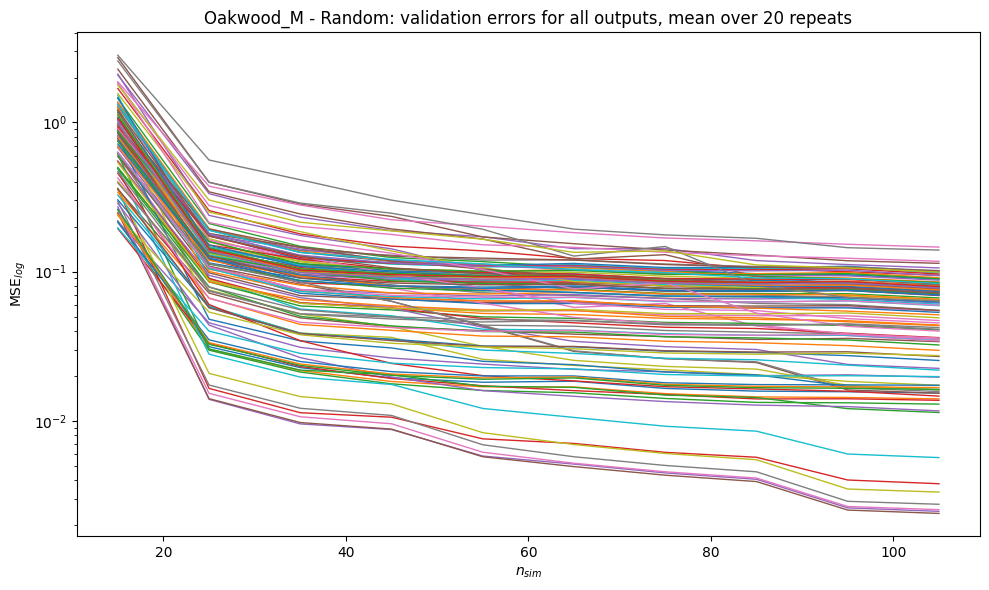

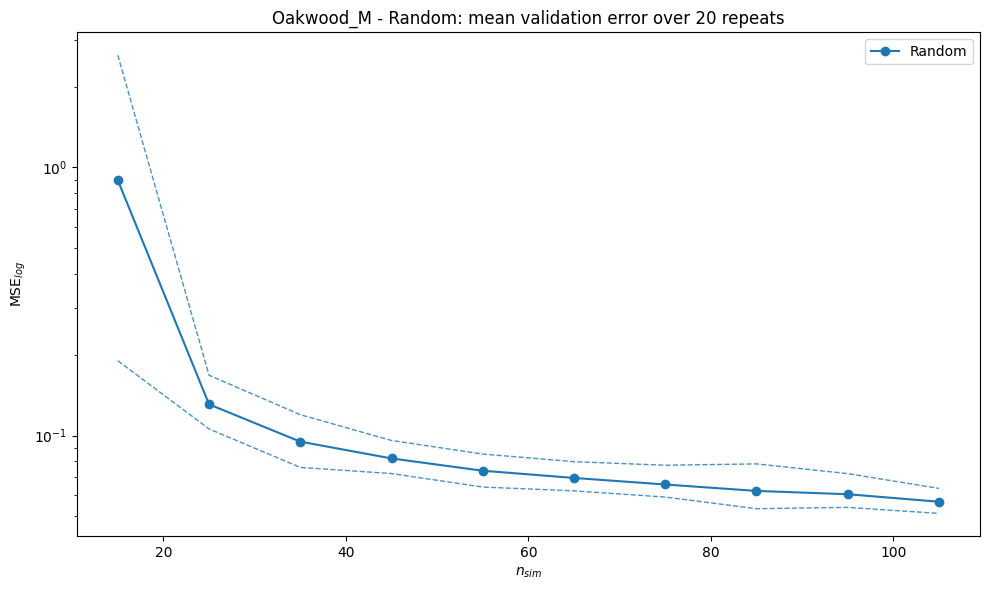

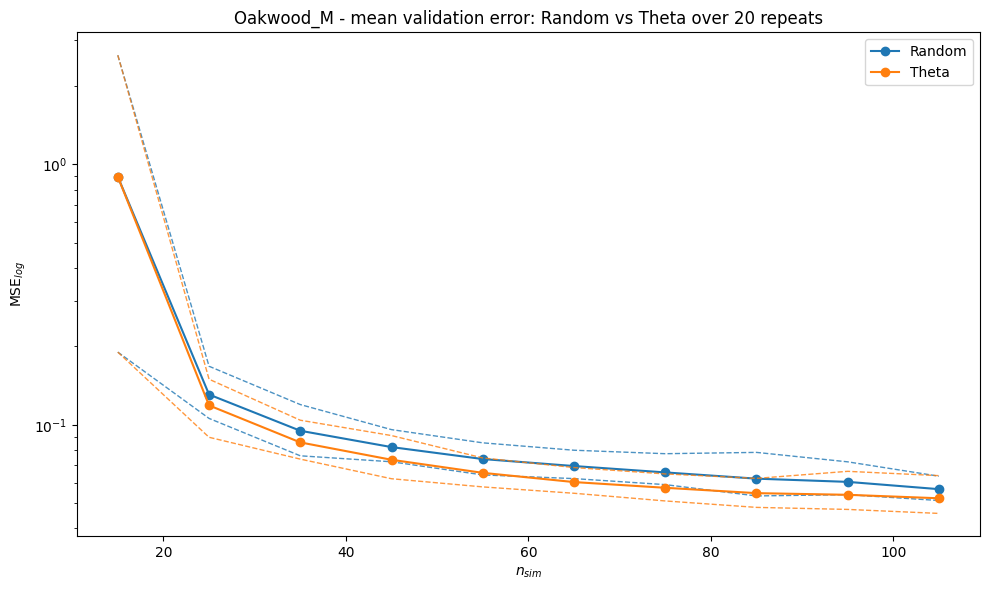

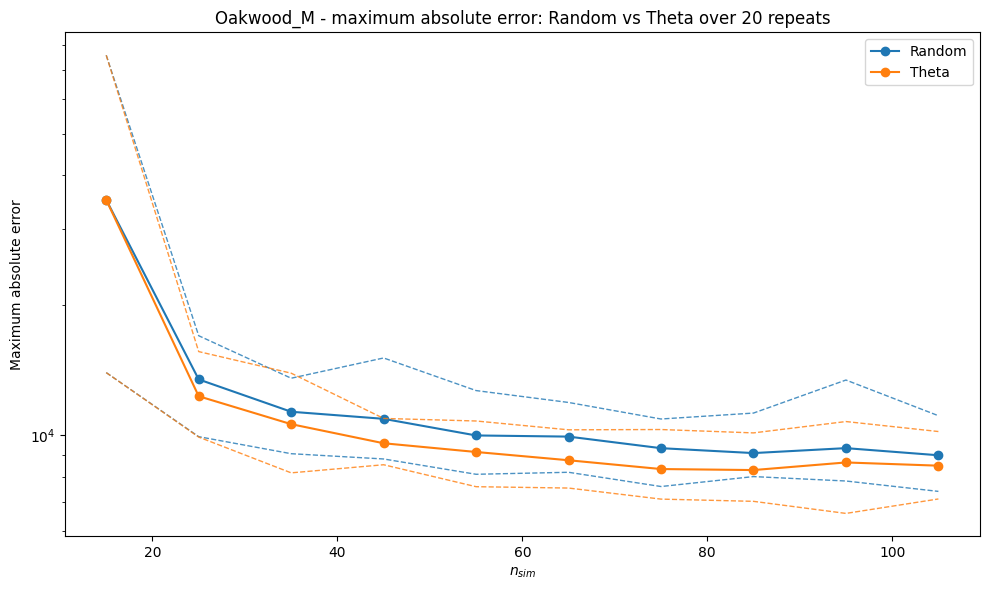

In [39]:
# Graf
def plot_mean_with_band(ax, x, curves, label):
    curves = np.asarray(curves, dtype=float)
    mean = np.nanmean(curves, axis=0)
    p05 = np.nanpercentile(curves, 5, axis=0)
    p95 = np.nanpercentile(curves, 95, axis=0)

    # hlavní křivka = průměr
    line, = ax.plot(x, mean, marker="o", label=label)

    # barva dané metody
    color = line.get_color()

    # dolní a horní okraj pásma = čárkované čáry
    ax.plot(x, p05, linestyle="--", linewidth=1, color=color, alpha=0.8)
    ax.plot(x, p95, linestyle="--", linewidth=1, color=color, alpha=0.8)


for dataset_name, repeats in all_outputs.items():
    # Graf všechny výstupní křivky pro Random, průměr přes opakování
    random_stack = np.asarray([
        rep["errs_by_method"]["Random"]
        for rep in repeats
    ])  # repeat x n_train x n_outputs
    errs_original_mean_outputs = np.nanmean(random_stack, axis=0)

    fig, ax = plt.subplots(figsize=(10, 6))
    for j in range(errs_original_mean_outputs.shape[1]):
        ax.plot(nsim, errs_original_mean_outputs[:, j], linewidth=1)

    ax.set_yscale("log")
    ax.set_ylabel("MSE$_{log}$")
    ax.set_xlabel("$n_{sim}$")
    ax.set_title(f"{dataset_name} - Random: validation errors for all outputs, mean over {N_REPEATS} repeats")
    plt.tight_layout()
    plt.show()

    # Mean pro Random se statistikou opakování
    fig, ax = plt.subplots(figsize=(10, 6))
    random_mean_curves = [
        np.nanmean(rep["errs_by_method"]["Random"], axis=1)
        for rep in repeats
    ]
    plot_mean_with_band(ax, nsim, random_mean_curves, "Random")
    ax.set_yscale("log")
    ax.set_ylabel("MSE$_{log}$")
    ax.set_xlabel("$n_{sim}$")
    ax.set_title(f"{dataset_name} - Random: mean validation error over {N_REPEATS} repeats")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Porovnání mean Random vs Theta se statistikou opakování
    fig, ax = plt.subplots(figsize=(10, 6))
    for method in METHODS:
        mean_curves = [
            np.nanmean(rep["errs_by_method"][method], axis=1)
            for rep in repeats
        ]

        plot_label = "Random" if method == "Random" else method
        plot_mean_with_band(ax, nsim, mean_curves, plot_label)

    ax.set_yscale("log")
    ax.set_ylabel("MSE$_{log}$")
    ax.set_xlabel("$n_{sim}$")
    ax.set_title(f"{dataset_name} - mean validation error: Random vs Theta over {N_REPEATS} repeats")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Maximum absolute error: Random vs Theta se statistikou opakování
    fig, ax = plt.subplots(figsize=(10, 6))
    for method in METHODS:
        max_abs_curves = [
            np.nanmax(rep["max_abs_by_method"][method], axis=1)
            for rep in repeats
        ]

        plot_label = "Random" if method == "Random" else method
        plot_mean_with_band(ax, nsim, max_abs_curves, plot_label)

    ax.set_yscale("log")
    ax.set_ylabel("Maximum absolute error")
    ax.set_xlabel("$n_{sim}$")
    ax.set_title(f"{dataset_name} - maximum absolute error: Random vs Theta over {N_REPEATS} repeats")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [27]:
# Kontrola Theta logů
for dataset_name, repeats in all_outputs.items():
    print("=" * 100)
    print(f"Theta logs: {dataset_name}")
    print("=" * 100)

    logs = []
    for rep in repeats:
        for row in rep["theta_logs"]:
            row = dict(row)
            row["repeat"] = rep["repeat"]
            row["seed"] = rep["seed"]
            logs.append(row)

    display(pd.DataFrame(logs))


Theta logs: Oakwood_M


,target_n,n_added,theta_status,train_size_after,candidate_pool_after,conversion_info,repeat,seed
0,25,10,theta,25,675,"{'coef_ok': True, 'pred_ok': True, 'n_single_p...",0,1
1,35,10,theta,35,665,"{'coef_ok': True, 'pred_ok': True, 'n_single_p...",0,1
2,45,10,theta,45,655,"{'coef_ok': True, 'pred_ok': True, 'n_single_p...",0,1
3,55,10,theta,55,645,"{'coef_ok': True, 'pred_ok': True, 'n_single_p...",0,1
4,65,10,theta,65,635,"{'coef_ok': True, 'pred_ok': True, 'n_single_p...",0,1
...,...,...,...,...,...,...,...,...
175,65,10,theta,65,635,"{'coef_ok': True, 'pred_ok': True, 'n_single_p...",19,20
176,75,10,theta,75,625,"{'coef_ok': True, 'pred_ok': True, 'n_single_p...",19,20
177,85,10,theta,85,615,"{'coef_ok': True, 'pred_ok': True, 'n_single_p...",19,20
178,95,10,theta,95,605,"{'coef_ok': True, 'pred_ok': True, 'n_single_p...",19,20
